In [50]:
import numpy as np
from os.path import abspath, exists
from scipy import sparse,stats
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd 

In [23]:

class PoliticalBlogsClustering:
    def __init__(self):
        pass

    def find_majority_labels(self, num_clusters = 2):
        '''
        This method loads the data, performs spectral clustering  and reports the majority labels

        Inputs:
            num_clusters (int): The number of clusters to be created

        Output:
            A map with following attributes
            1. overall_mismatch_rate: <2 decimal places>
            2. mismatch_rates: [{"majority_index": <int>, "mismatch_rate": <2 decimal places>}]
        '''

        map = {
            "overall_mismatch_rate": None,
            "mismatch_rates": []
        }

        # TODO - start your implementation.
        ## It is suggested to break your code into smaller methods but not nessasary. 

        def import_nodes_and_edges(node_path,edge_path):

            nodes = []
            with open(node_path) as f:
                for line in f:
                    n= line.split("\t")
                    n[0] = int(n[0])
                    n[1] = n[1].strip('"')
                    n[2] = int(n[2])
                    n[3] = n[3].strip('"')
                    nodes.append(n)
            edges=np.loadtxt(edge_path, dtype=int)

            return nodes,edges
        def clean_nodes_and_edges(nodes,edges):
            node_assignment_dict = {e[0]:e[2] for e in nodes}
            edges_no_self_loop = edges[edges[:,0]!=edges[:,1]]
            edges_de_dupe = np.unique(np.sort(edges_no_self_loop, axis=1), axis=0)

            nodes_used = np.unique(edges_de_dupe)

            new_node_map = {old: new for new, old in enumerate(nodes_used)}
            new_node_map_inv = {v:k for k,v in new_node_map.items()}
            
            return node_assignment_dict,edges_de_dupe,nodes_used,new_node_map,new_node_map_inv
        
        def lap_matrix_construction(node_map,edges,nodes_used):

            i = np.array([node_map[n1] for n1 in edges[:, 0]])
            j = np.array([node_map[n2] for n2 in edges[:, 1]])
            v = np.ones(len(i))

            A = sparse.coo_matrix((v, (i, j)), shape=(len(nodes_used), len(nodes_used)))
            A = A + A.T  
            A= sparse.csc_matrix.todense(A) 
            
            D = np.diag(np.sum(A, axis=1).A1)

            L= D-A

            return L
        
        def construct_Z_matrix(L):

            v, x = np.linalg.eig(L)

            idx_sorted = np.argsort(v)
            Z = x[:, idx_sorted[:num_clusters]]
            row_vec_norm = np.linalg.norm(Z, axis=1, keepdims=True) #https://stackoverflow.com/questions/68227583/np-linalg-norm-axiserror-axis-1-is-out-of-bounds-for-array-of-dimension-1

            Z_normalized = Z / row_vec_norm
            Z_normalized=np.array(Z_normalized)

            return Z_normalized
        
        def k_means_and_accuracy(Z,node_assignment_dict,new_node_map_inv,nodes_used):
            kmeans=KMeans(n_clusters=num_clusters).fit(Z.real)

            labels = kmeans.labels_

            label_assignment_dict = {ks+1:np.where(labels == ks)[0] for ks in range(num_clusters)}

            cluster_lable_dict = {}
            for k,v in label_assignment_dict.items():
                k_list = []
                for e in v:
                    k_list.append(node_assignment_dict[new_node_map_inv[e]])
                
                cluster_lable_dict[k] = k_list


            cluster_lable_and_mismatch_dict =[]
            running_mismath_total = 0

            for k,v in cluster_lable_dict.items():
                cluster_lable_and_mismatch_dict.append({'majority_index':k,"mismatch_rate":round((len(cluster_lable_dict[k])-stats.mode(cluster_lable_dict[k])[1])/len(cluster_lable_dict[k]),2)})
                running_mismath_total+=(len(cluster_lable_dict[k])-stats.mode(cluster_lable_dict[k])[1])

            round(running_mismath_total/len(nodes_used),2)


            return cluster_lable_and_mismatch_dict,round(running_mismath_total/len(nodes_used),2)



        nodes,edges=import_nodes_and_edges('data/nodes.txt','data/edges.txt')

        node_assignment_dict,edges_de_dupe,nodes_used,new_node_map,new_node_map_inv = clean_nodes_and_edges(nodes,edges)

        L = lap_matrix_construction(new_node_map,edges_de_dupe,nodes_used)

        Z = construct_Z_matrix(L)

        cluster_assignments,mismatch_rate = k_means_and_accuracy(Z,node_assignment_dict,new_node_map_inv,nodes_used)

            
        map['overall_mismatch_rate'] = mismatch_rate
        map['mismatch_rates'] = cluster_assignments
            



        return map 


In [48]:
ks=[2,5,10,30,50]
overall_error = []
mismatch_rates_list = []
majority_index_list = []
k_map = []



for k in ks:
    clusters = PoliticalBlogsClustering()
    output_dict = clusters.find_majority_labels(k)
    overall_error.append(output_dict['overall_mismatch_rate'])
    for e in output_dict['mismatch_rates']:
        k_map.append(k)
        mismatch_rates_list.append(e['mismatch_rate'])
        majority_index_list.append(e['majority_index'])


In [49]:
overall_error

[np.float64(0.48),
 np.float64(0.48),
 np.float64(0.46),
 np.float64(0.05),
 np.float64(0.05)]

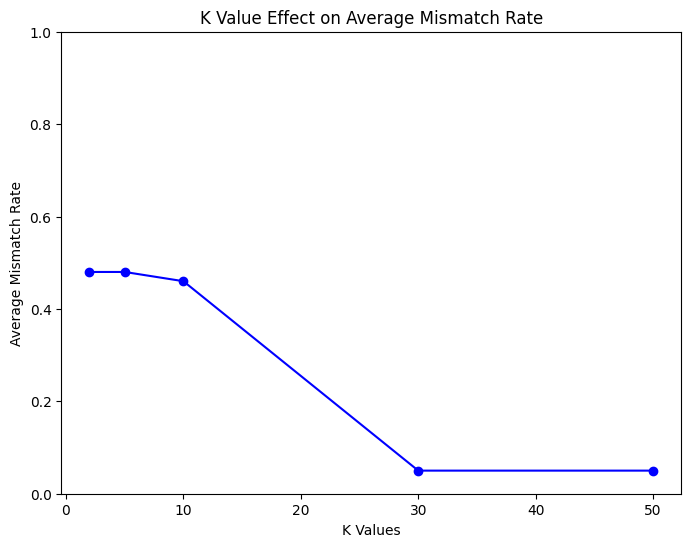

In [53]:
#https://www.geeksforgeeks.org/data-science/draw-multiple-y-axis-scales-in-matplotlib/

fig, ax1 = plt.subplots(figsize= (8,6))
ax1.plot(ks,overall_error,'b',label="Average Mismatch Rate",marker='o')

ax1.set_xlabel('K Values')
ax1.set_ylabel("Average Mismatch Rate")
ax1.tick_params('y')
ax1.set_ylim(0, 1)

plt.title('K Value Effect on Average Mismatch Rate')

plt.show()


In [ ]:
mismatch_rate_per_cluster_label = pd.DataFrame({'k':k_map,'majority_index':majority_index_list,'mismatch_rate':mismatch_rates_list})

print(mismatch_rate_per_cluster_label)

     k  majority_index  mismatch_rate
0    2               1           0.48
1    2               2           0.00
2    5               1           0.48
3    5               2           0.00
4    5               3           0.20
..  ..             ...            ...
92  50              46           0.00
93  50              47           0.00
94  50              48           0.00
95  50              49           0.00
96  50              50           0.00

[97 rows x 3 columns]


In [58]:
ks_tunning=[i for i in range(20,210,10)]


In [65]:
ks_tunning=[i for i in range(20,310,10)]
overall_error_tunning = []
mismatch_rates_list_tunning = []
majority_index_list_tunning = []
k_map_tunning = []



for k in ks_tunning:
    clusters = PoliticalBlogsClustering()
    output_dict = clusters.find_majority_labels(k)
    overall_error_tunning.append(output_dict['overall_mismatch_rate'])
    for e in output_dict['mismatch_rates']:
        k_map_tunning.append(k)
        mismatch_rates_list_tunning.append(e['mismatch_rate'])
        majority_index_list_tunning.append(e['majority_index'])

In [68]:
pd.DataFrame({"k":ks_tunning,"overall_mismatch_rate":overall_error_tunning})

,k,overall_mismatch_rate
0,20,0.05
1,30,0.04
2,40,0.05
3,50,0.05
4,60,0.04
5,70,0.04
6,80,0.04
7,90,0.04
8,100,0.04
9,110,0.05


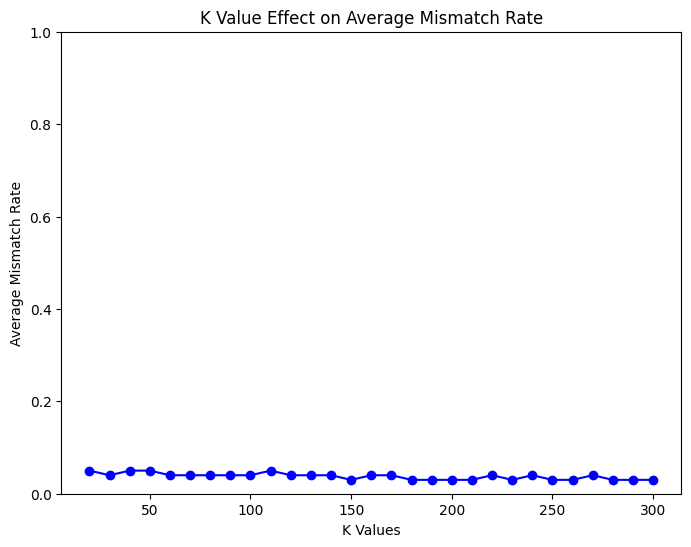

In [67]:
fig, ax1 = plt.subplots(figsize= (8,6))
ax1.plot(ks_tunning,overall_error_tunning,'b',label="Average Mismatch Rate",marker='o')

ax1.set_xlabel('K Values')
ax1.set_ylabel("Average Mismatch Rate")
ax1.tick_params('y')
ax1.set_ylim(0, 1)

plt.title('K Value Effect on Average Mismatch Rate')

plt.show()


Q 3.2

- To tune the value of K, clustering performance was evaluated using the mismatch rate as the primary metric. Initial results showed that the mismatch rate declined significantly between K=10 and K=30. Based on this observation, values of K ranging from 10 to 300 were tested in increments of 10 to identify the value of K that minimizes the mismatch rate.
- As K increased, the improvement in mismatch rate exhibited diminishing returns. Between K=20 and K=300, the mismatch rate improved by only about 2%. Given this marginal gain, K=20 was selected as it achieved a mismatch rate of approximately 5% while maintaining lower model complexity. Increasing K beyond this point resulted in only minor improvements.
- This result suggests that the network contains strongly defined communities, as increasing the number of clusters does not significantly improve clustering accuracy. This implies that nodes within the same community are highly connected, while connections between different communities are sparse, making the community structure more simple to detect. Although, as the mismatch rate stays relatively steady from K =20 onwards, this does indicate that although some nodes belong to speperate comunities there is still some level on connectivity between them. 